# Brighten ROI Nail Crops — lossless PNG pipeline

**Goal:** take the output folder from your ROI scaling pipeline and create a brightened version without resizing, without JPEG re-compression, and with reports to verify that every nail crop was processed.

What this notebook does:

1. Scans one ROI-output folder recursively.
2. Computes nail/foreground brightness using the **Y channel** in YCrCb, ignoring black/transparent background.
3. Brightens dark crops only by default (`BRIGHTEN_MODE = "auto"`). You can set `"all"` if you want every crop enhanced.
4. Saves results as **PNG** with the same pixel dimensions.
5. Preserves alpha channel and keeps black background unchanged.
6. Creates CSV reports and a before/after contact sheet.

This version is designed for a folder of already-cropped ROI nail images.

## 0) Imports

In [1]:
from pathlib import Path
import shutil, hashlib, json, math, os
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt

# Optional SCI support
import sys, importlib, inspect, re
try:
    import torch
    TORCH_AVAILABLE = True
except Exception:
    TORCH_AVAILABLE = False


## 1) Configure paths and behavior

In [2]:
# ===== EDIT THESE =====
# Folder from your ROI scaling pipeline. Put your real ROI output folder here.
INPUT_ROOT = Path('/Users/williamtsai/Desktop/NTHU 3.2/special topic/will data/pre_process/seg_scale/usable_nail_crops_roi102_flat/usable_nail_crops_roi102_flat_images')

# Notebook folder. In Jupyter, Path.cwd() is usually the folder where this notebook is located.
# Put this notebook in the folder where you want the outputs to appear, then run it.
NOTEBOOK_DIR = Path.cwd()

# Output folder. Default: SAME FOLDER AS THIS NOTEBOOK, named '<input>_brightened'.
OUTPUT_ROOT = NOTEBOOK_DIR / f"{INPUT_ROOT.name}_brightened"

# Reports folder. Default: SAME FOLDER AS THIS NOTEBOOK.
REPORT_DIR = NOTEBOOK_DIR / f"{OUTPUT_ROOT.name}_reports"

# Save output directly under OUTPUT_ROOT instead of mirroring subfolders.
# This matches your recent preference: output not in subfolders.
FLATTEN_OUTPUT = True

# Brightening mode:
#   "auto" = only brighten dark crops below Y_THRESH
#   "all"  = brighten every readable crop
#   "copy" = no brightening, just verify/copy as PNG
BRIGHTEN_MODE = "auto"

# Method:
#   "safe_y_gamma" = local, stable, no internet/model needed; recommended for dataset consistency
#   "sci"          = try SCI TPAMI model; falls back to safe_y_gamma if unavailable
METHOD = "safe_y_gamma"

# Brightness threshold on non-background Y channel.
Y_THRESH = 70

# Conservative target brightness for dark crops. Increase slowly if crops are still too dark.
TARGET_MEAN_Y = 105

# Background threshold: pixels where all BGR channels <= this are treated as black background.
BLACK_RGB_THRESH = 5

# Output PNG compression. PNG is lossless; 0 is fastest/largest, 3 is still lossless and smaller.
PNG_COMPRESSION = 3

# Supported input formats
EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("INPUT_ROOT :", INPUT_ROOT)
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("REPORT_DIR :", REPORT_DIR)
print("FLATTEN_OUTPUT:", FLATTEN_OUTPUT)
print("BRIGHTEN_MODE:", BRIGHTEN_MODE)
print("METHOD:", METHOD)


INPUT_ROOT : /Users/williamtsai/Desktop/NTHU 3.2/special topic/will data/pre_process/seg_scale/usable_nail_crops_roi102_flat/usable_nail_crops_roi102_flat_images
OUTPUT_ROOT: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will data/pre_process/brighten/usable_nail_crops_roi102_flat_images_brightened
REPORT_DIR : /Users/williamtsai/Desktop/NTHU 3.2/special topic/will data/pre_process/brighten/usable_nail_crops_roi102_flat_images_brightened_reports
FLATTEN_OUTPUT: True
BRIGHTEN_MODE: auto
METHOD: safe_y_gamma


## 2) Optional: SCI TPAMI setup (only needed if `METHOD = "sci"`)

In [3]:
# Leave this cell as-is if METHOD = "safe_y_gamma".
# If you want SCI, clone/download https://github.com/vis-opt-group/SCI and set SCI_REPO_DIR.
# In Colab/Jupyter with internet, you may uncomment the git clone line.

SCI_REPO_DIR = Path("./SCI")
# if METHOD == "sci" and not SCI_REPO_DIR.exists():
#     !git clone https://github.com/vis-opt-group/SCI.git

TPAMI_DIR = SCI_REPO_DIR / "TPAMI"
print("TORCH_AVAILABLE:", TORCH_AVAILABLE)
print("TPAMI_DIR:", TPAMI_DIR.resolve())
print("TPAMI_DIR exists?", TPAMI_DIR.exists())


TORCH_AVAILABLE: False
TPAMI_DIR: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will data/pre_process/brighten/SCI/TPAMI
TPAMI_DIR exists? False


## 3) Helper functions

In [4]:
def imread_unchanged(path: Path):
    """Read image without dropping alpha. Returns None if unreadable."""
    return cv2.imread(str(path), cv2.IMREAD_UNCHANGED)


def ensure_bgra_or_bgr(img: np.ndarray):
    """Normalize grayscale/odd formats to BGR/BGRA for consistent processing."""
    if img is None:
        return None
    if img.ndim == 2:
        return cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    if img.ndim == 3 and img.shape[2] == 1:
        return cv2.cvtColor(img[:, :, 0], cv2.COLOR_GRAY2BGR)
    if img.ndim == 3 and img.shape[2] in (3, 4):
        return img
    raise ValueError(f"Unsupported image shape: {img.shape}")


def foreground_mask(img: np.ndarray, black_thresh=5):
    """Return uint8 mask where 1 = nail/foreground, 0 = black/transparent background."""
    bgr = img[:, :, :3]
    nonblack = (bgr[:, :, 0] > black_thresh) | (bgr[:, :, 1] > black_thresh) | (bgr[:, :, 2] > black_thresh)
    if img.shape[2] == 4:
        nontransparent = img[:, :, 3] > 0
        nonblack = nonblack & nontransparent
    return nonblack.astype(np.uint8)


def mean_y_foreground(img: np.ndarray, mask01: np.ndarray):
    """Mean luminance Y over foreground only."""
    bgr = img[:, :, :3]
    ycrcb = cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb)
    y = ycrcb[:, :, 0]
    vals = y[mask01 == 1]
    if vals.size == 0:
        return None
    return float(vals.mean())


def output_path_for(in_path: Path, input_root: Path, output_root: Path, flatten=True):
    """Map input file to output PNG path. Avoid filename collisions when flattening."""
    rel = in_path.relative_to(input_root)
    if not flatten:
        return (output_root / rel).with_suffix(".png")

    name = in_path.stem + ".png"
    out = output_root / name
    if out.exists() and in_path.parent != input_root:
        parent_key = str(rel.parent).replace(os.sep, "_")
        h = hashlib.sha1(str(rel.parent).encode("utf-8")).hexdigest()[:8]
        out = output_root / f"{in_path.stem}__{parent_key}_{h}.png"
    return out


def write_png_lossless(path: Path, img: np.ndarray):
    path.parent.mkdir(parents=True, exist_ok=True)
    ok = cv2.imwrite(str(path), img, [cv2.IMWRITE_PNG_COMPRESSION, PNG_COMPRESSION])
    if not ok:
        raise IOError(f"cv2.imwrite failed: {path}")


def preserve_background_and_alpha(original: np.ndarray, enhanced_bgr: np.ndarray, mask01: np.ndarray):
    """Use enhanced pixels only on foreground; preserve original black background and alpha."""
    orig3 = original[:, :, :3].astype(np.float32)
    enh3 = enhanced_bgr[:, :, :3].astype(np.float32)
    m = mask01[:, :, None].astype(np.float32)
    out3 = (enh3 * m + orig3 * (1.0 - m)).clip(0, 255).astype(np.uint8)
    if original.shape[2] == 4:
        return np.dstack([out3, original[:, :, 3]])
    return out3


## 4) Brightening methods

In [5]:
def brighten_safe_y_gamma(img: np.ndarray, mask01: np.ndarray, target_mean_y=105):
    """
    Conservative local brightening:
    - Convert BGR -> YCrCb
    - Gamma-correct only Y channel toward TARGET_MEAN_Y
    - Apply mild CLAHE only to foreground area
    - Keep Cr/Cb color channels unchanged as much as possible
    """
    bgr = img[:, :, :3]
    ycrcb = cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb)
    y = ycrcb[:, :, 0].astype(np.float32)
    vals = y[mask01 == 1]
    if vals.size == 0:
        return bgr.copy()

    mean_y = max(float(vals.mean()), 1.0)
    target = float(target_mean_y)

    gamma = math.log(target / 255.0) / math.log(mean_y / 255.0)
    gamma = float(np.clip(gamma, 0.50, 0.95))

    y_norm = np.clip(y / 255.0, 0, 1)
    y_gamma = (np.power(y_norm, gamma) * 255.0).clip(0, 255).astype(np.uint8)

    clahe = cv2.createCLAHE(clipLimit=1.4, tileGridSize=(8, 8))
    y_clahe = clahe.apply(y_gamma)

    y_new = (0.80 * y_gamma.astype(np.float32) + 0.20 * y_clahe.astype(np.float32)).clip(0, 255).astype(np.uint8)
    y_out = y.astype(np.uint8).copy()
    y_out[mask01 == 1] = y_new[mask01 == 1]

    ycrcb[:, :, 0] = y_out
    return cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR)


# ---- Optional SCI helpers ----
def find_easy_weight(tpami_dir: Path):
    candidates = []
    for root in [tpami_dir / "weights", tpami_dir]:
        if root.exists():
            candidates += list(root.rglob("*"))
    weights = [p for p in candidates if p.is_file() and p.suffix.lower() in {".pth", ".pt"}]
    easy = [p for p in weights if "easy" in p.name.lower()]
    chosen = easy or weights
    return sorted(chosen, key=lambda p: (len(str(p)), str(p)))[0] if chosen else None


def find_model_class(tpami_dir: Path):
    sys.path.insert(0, str(tpami_dir))
    preferred = ["SCI", "Network", "Net", "Model", "EnhanceNet"]
    for py in sorted(tpami_dir.rglob("*.py"), key=lambda p: len(str(p))):
        text = py.read_text(errors="ignore")
        for cname in preferred:
            if re.search(rf"^class\s+{cname}\b", text, flags=re.M):
                modname = ".".join(py.relative_to(tpami_dir).with_suffix("").parts)
                try:
                    mod = importlib.import_module(modname)
                    cls = getattr(mod, cname, None)
                    if inspect.isclass(cls):
                        return cls, modname
                except Exception:
                    pass
    return None, None


def try_load_sci(tpami_dir: Path):
    if not TORCH_AVAILABLE or not tpami_dir.exists():
        return None, None, "torch_or_tpami_missing"
    device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
    cls, modname = find_model_class(tpami_dir)
    if cls is None:
        return None, device, "model_class_not_found"
    weight = find_easy_weight(tpami_dir)
    if weight is None:
        return None, device, "weight_not_found"
    try:
        model = cls().to(device)
        ckpt = torch.load(str(weight), map_location=device)
        state = ckpt.get("state_dict", ckpt.get("model", ckpt)) if isinstance(ckpt, dict) else ckpt
        new_state = {k.replace("module.", ""): v for k, v in state.items()} if isinstance(state, dict) else state
        model.load_state_dict(new_state, strict=False)
        model.eval()
        return model, device, f"loaded {modname} with {weight.name}"
    except Exception as e:
        return None, device, f"load_failed: {type(e).__name__}: {e}"


if TORCH_AVAILABLE:
    @torch.no_grad()
    def brighten_sci(model, device, img: np.ndarray):
        bgr = img[:, :, :3]
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        x = torch.from_numpy(rgb).float().permute(2, 0, 1).unsqueeze(0).to(device) / 255.0
        out = model(x)
        while isinstance(out, (list, tuple)):
            out = out[0]
        out = out.clamp(0, 1)
        arr = (out.squeeze(0).permute(1, 2, 0).detach().cpu().numpy() * 255).clip(0, 255).astype(np.uint8)
        return cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)
else:
    def brighten_sci(model, device, img: np.ndarray):
        raise RuntimeError("torch is not available")


## 5) Run pipeline

In [6]:
assert INPUT_ROOT.exists(), f"INPUT_ROOT does not exist: {INPUT_ROOT}"
assert BRIGHTEN_MODE in {"auto", "all", "copy"}
assert METHOD in {"safe_y_gamma", "sci"}

sci_model, sci_device, sci_status = (None, None, "not_requested")
if METHOD == "sci":
    sci_model, sci_device, sci_status = try_load_sci(TPAMI_DIR)
    print("SCI status:", sci_status)
    if sci_model is None:
        print("SCI unavailable; falling back to safe_y_gamma for this run.")

all_files = sorted([p for p in INPUT_ROOT.rglob("*") if p.is_file()])
image_files = [p for p in all_files if p.suffix.lower() in EXTS]
print("Total files found:", len(all_files))
print("Image files found:", len(image_files))

records = []
used_output_names = set()

for in_path in tqdm(image_files):
    rel = in_path.relative_to(INPUT_ROOT)
    out_path = output_path_for(in_path, INPUT_ROOT, OUTPUT_ROOT, flatten=FLATTEN_OUTPUT)

    if out_path.name in used_output_names:
        h = hashlib.sha1(str(rel).encode("utf-8")).hexdigest()[:8]
        out_path = out_path.with_name(f"{out_path.stem}__{h}.png")
    used_output_names.add(out_path.name)

    rec = {
        "input_path": str(in_path), "relative_path": str(rel), "output_path": str(out_path),
        "input_ext": in_path.suffix.lower(), "status": None, "method_used": None,
        "meanY_before": None, "meanY_after": None, "brightened": 0,
        "input_h": None, "input_w": None, "output_h": None, "output_w": None,
        "has_alpha": None, "same_shape": None, "error": None,
    }

    try:
        img = ensure_bgra_or_bgr(imread_unchanged(in_path))
        if img is None:
            rec["status"] = "read_fail"
            records.append(rec)
            continue

        rec["input_h"], rec["input_w"] = img.shape[:2]
        rec["has_alpha"] = int(img.shape[2] == 4)
        mask = foreground_mask(img, BLACK_RGB_THRESH)
        mean_before = mean_y_foreground(img, mask)
        rec["meanY_before"] = mean_before

        if mean_before is None:
            if in_path.suffix.lower() == ".png":
                out_path.parent.mkdir(parents=True, exist_ok=True)
                shutil.copy2(in_path, out_path)
            else:
                write_png_lossless(out_path, img)
            rec["status"] = "no_foreground_copied"
            out_img = ensure_bgra_or_bgr(imread_unchanged(out_path))
            rec["output_h"], rec["output_w"] = out_img.shape[:2]
            rec["same_shape"] = int(out_img.shape[:2] == img.shape[:2])
            records.append(rec)
            continue

        should_brighten = (BRIGHTEN_MODE == "all") or (BRIGHTEN_MODE == "auto" and mean_before < Y_THRESH)

        if BRIGHTEN_MODE == "copy" or not should_brighten:
            if in_path.suffix.lower() == ".png":
                out_path.parent.mkdir(parents=True, exist_ok=True)
                shutil.copy2(in_path, out_path)
            else:
                write_png_lossless(out_path, img)
            rec["status"] = "copied_not_dark" if not should_brighten else "copied_copy_mode"
            rec["method_used"] = "copy"
        else:
            if METHOD == "sci" and sci_model is not None:
                try:
                    enhanced_bgr = brighten_sci(sci_model, sci_device, img)
                    method_used = "sci"
                except Exception as e:
                    enhanced_bgr = brighten_safe_y_gamma(img, mask, TARGET_MEAN_Y)
                    method_used = f"safe_y_gamma_after_sci_error:{type(e).__name__}"
            else:
                enhanced_bgr = brighten_safe_y_gamma(img, mask, TARGET_MEAN_Y)
                method_used = "safe_y_gamma"

            out_img = preserve_background_and_alpha(img, enhanced_bgr, mask)
            write_png_lossless(out_path, out_img)
            rec["status"] = "enhanced"
            rec["method_used"] = method_used
            rec["brightened"] = 1

        out_img = ensure_bgra_or_bgr(imread_unchanged(out_path))
        rec["output_h"], rec["output_w"] = out_img.shape[:2]
        rec["same_shape"] = int(out_img.shape[:2] == img.shape[:2])
        rec["meanY_after"] = mean_y_foreground(out_img, mask)

    except Exception as e:
        rec["status"] = "error"
        rec["error"] = f"{type(e).__name__}: {e}"

    records.append(rec)

log_df = pd.DataFrame(records)
log_csv = REPORT_DIR / "brighten_log.csv"
log_df.to_csv(log_csv, index=False, encoding="utf-8-sig")

print("Saved output folder:", OUTPUT_ROOT)
print("Saved log:", log_csv)
print("Processed records:", len(log_df))
print(log_df["status"].value_counts(dropna=False))
print("Brightened:", int(log_df["brightened"].sum()))


Total files found: 3467
Image files found: 3467


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3467/3467 [00:05<00:00, 583.99it/s]

Saved output folder: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will data/pre_process/brighten/usable_nail_crops_roi102_flat_images_brightened
Saved log: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will data/pre_process/brighten/usable_nail_crops_roi102_flat_images_brightened_reports/brighten_log.csv
Processed records: 3467
status
copied_not_dark    3311
enhanced            156
Name: count, dtype: int64
Brightened: 156


## 6) Verification reports

In [7]:
expected = len(image_files)
actual_outputs = sorted([p for p in OUTPUT_ROOT.rglob("*.png") if p.is_file()])

missing_df = log_df[~log_df["output_path"].apply(lambda x: Path(x).exists())].copy()
zero_df = log_df[log_df["output_path"].apply(lambda x: Path(x).exists() and Path(x).stat().st_size == 0)].copy()
shape_df = log_df[log_df["same_shape"] == 0].copy()
error_df = log_df[log_df["status"].isin(["read_fail", "error"])].copy()

missing_df.to_csv(REPORT_DIR / "missing_outputs.csv", index=False, encoding="utf-8-sig")
zero_df.to_csv(REPORT_DIR / "zero_byte_outputs.csv", index=False, encoding="utf-8-sig")
shape_df.to_csv(REPORT_DIR / "shape_mismatch.csv", index=False, encoding="utf-8-sig")
error_df.to_csv(REPORT_DIR / "errors.csv", index=False, encoding="utf-8-sig")

summary = {
    "input_root": str(INPUT_ROOT), "output_root": str(OUTPUT_ROOT), "report_dir": str(REPORT_DIR),
    "image_inputs_found": expected, "png_outputs_found": len(actual_outputs),
    "records_written": len(log_df), "brightened_count": int(log_df["brightened"].sum()),
    "missing_outputs": int(len(missing_df)), "zero_byte_outputs": int(len(zero_df)),
    "shape_mismatches": int(len(shape_df)), "read_or_processing_errors": int(len(error_df)),
    "mode": BRIGHTEN_MODE, "method": METHOD, "sci_status": sci_status,
}

with open(REPORT_DIR / "summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(json.dumps(summary, indent=2, ensure_ascii=False))

if summary["missing_outputs"] == 0 and summary["zero_byte_outputs"] == 0 and summary["shape_mismatches"] == 0 and summary["read_or_processing_errors"] == 0:
    print("✅ Verification passed: every readable input has a nonzero PNG output with the same dimensions.")
else:
    print("⚠️ Check the CSV reports in REPORT_DIR before using the dataset.")


{
  "input_root": "/Users/williamtsai/Desktop/NTHU 3.2/special topic/will data/pre_process/seg_scale/usable_nail_crops_roi102_flat/usable_nail_crops_roi102_flat_images",
  "output_root": "/Users/williamtsai/Desktop/NTHU 3.2/special topic/will data/pre_process/brighten/usable_nail_crops_roi102_flat_images_brightened",
  "report_dir": "/Users/williamtsai/Desktop/NTHU 3.2/special topic/will data/pre_process/brighten/usable_nail_crops_roi102_flat_images_brightened_reports",
  "image_inputs_found": 3467,
  "png_outputs_found": 3467,
  "records_written": 3467,
  "brightened_count": 156,
  "missing_outputs": 0,
  "zero_byte_outputs": 0,
  "shape_mismatches": 0,
  "read_or_processing_errors": 0,
  "mode": "auto",
  "method": "safe_y_gamma",
  "sci_status": "not_requested"
}
✅ Verification passed: every readable input has a nonzero PNG output with the same dimensions.


## 7) Visual sanity check: before/after contact sheet

Saved contact sheet: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will data/pre_process/brighten/usable_nail_crops_roi102_flat_images_brightened_reports/before_after_contact_sheet.png


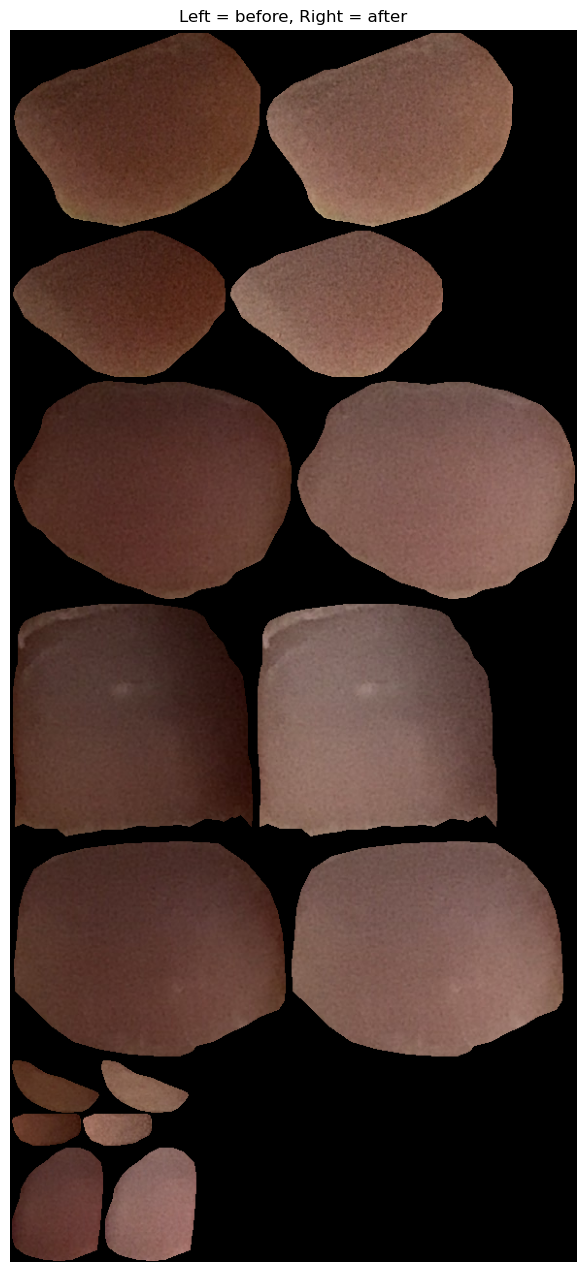

In [8]:
def to_rgb_for_display(img):
    img = ensure_bgra_or_bgr(img)
    bgr = img[:, :, :3]
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

sample_df = log_df[log_df["brightened"] == 1].copy()
if len(sample_df) == 0:
    sample_df = log_df.copy()

sample_df = sample_df.head(8)
rows = []
for _, row in sample_df.iterrows():
    a = imread_unchanged(Path(row["input_path"]))
    b = imread_unchanged(Path(row["output_path"]))
    if a is None or b is None:
        continue
    ar = to_rgb_for_display(a)
    br = to_rgb_for_display(b)
    if ar.shape[:2] != br.shape[:2]:
        continue
    rows.append(np.concatenate([ar, br], axis=1))

if rows:
    maxw = max(r.shape[1] for r in rows)
    padded = []
    for r in rows:
        if r.shape[1] < maxw:
            pad = np.zeros((r.shape[0], maxw-r.shape[1], 3), dtype=np.uint8)
            r = np.concatenate([r, pad], axis=1)
        padded.append(r)
    sheet = np.concatenate(padded, axis=0)
    sheet_path = REPORT_DIR / "before_after_contact_sheet.png"
    cv2.imwrite(str(sheet_path), cv2.cvtColor(sheet, cv2.COLOR_RGB2BGR), [cv2.IMWRITE_PNG_COMPRESSION, PNG_COMPRESSION])
    print("Saved contact sheet:", sheet_path)
    plt.figure(figsize=(10, max(4, len(rows)*2)))
    plt.imshow(sheet)
    plt.title("Left = before, Right = after")
    plt.axis("off")
    plt.show()
else:
    print("No examples available to show.")


## 8) How to use the output for the next step

Use `OUTPUT_ROOT` as the image folder for the next preprocessing/model step. With the current settings, both output and reports are saved in the same folder where this notebook is running. The important files are:

- `OUTPUT_ROOT`: brightened PNG crops
- `REPORT_DIR/brighten_log.csv`: per-image processing log
- `REPORT_DIR/summary.json`: count summary
- `REPORT_DIR/before_after_contact_sheet.png`: quick visual check